<h1>Python pipeline for a basic time series analysis<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Signal-filtering" data-toc-modified-id="Signal-filtering-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Signal filtering</a></span></li><li><span><a href="#Exercise-1" data-toc-modified-id="Exercise-1-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Exercise 1</a></span></li><li><span><a href="#Exercise-2" data-toc-modified-id="Exercise-2-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Exercise 2</a></span></li><li><span><a href="#Exercise-3" data-toc-modified-id="Exercise-3-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Exercise 3</a></span></li><li><span><a href="#Excursus:-Moni's-heatmap-problem" data-toc-modified-id="Excursus:-Moni's-heatmap-problem-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Excursus: Moni's heatmap problem</a></span></li></ul></div>

## Signal filtering

Create a script including the following commands:

In [1]:
# Create some dummy data:
import numpy as np
import matplotlib.pyplot as plt 
       # imports most relevant Matplotlib commands

# create x-values:
dx = 0.1
x_values = np.arange(0, 2*np.pi, dx)

# define parameters:
f1 = 2  # Frequency 1 in Hz
f2 = 10 # Frequency 2 in Hz
A1 = 6 # Amplitude 1
A2 = 2 # Amplitude 2

A_sin = A1 * np.sin(f1 * x_values)
A_cos = A2 * np.cos(f2 * x_values)
A_signal = A_sin + A_cos

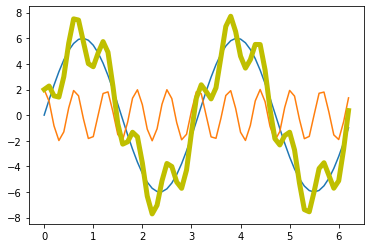

In [2]:
fig=plt.figure(1)
plt.plot(x_values, A_sin)
plt.plot(x_values, A_cos)
plt.plot(x_values, A_signal, lw=5, c="y")
plt.show()

Now, we add some noise to the signal:

In [3]:
np.random.seed(1)
A_Noise = 2
Noise = np.random.randn(len(x_values)) * A_Noise
A_signal_noisy = A_signal + Noise

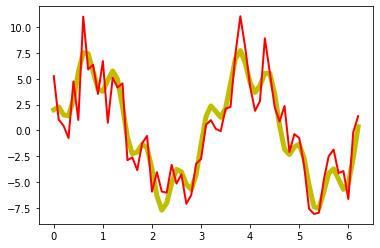

In [4]:
fig=plt.figure(1)
plt.plot(x_values, A_signal, lw=5, c="y")
plt.plot(x_values, A_signal_noisy, lw=2, c="r")
plt.show()

## Exercise 1
Basing on your solution of Exercise 1 from the _Data Visualization with Matplotlib_ chapter, copy and modify the appropriate plot commands, in order to plot

1. `A_signal` (add the following properties to the plot command: `label="Signal", lw=2, c="pink"`)
2. `A_signal_noisy` (add the following properties to the plot command: `label="Noisy signal", lw=3, c="lime"`)
    
in a single plot window. Don't forget to annotate your plot with appropriate _x_- and _y_-labels, a title, and a legend. Also, save your plot as a PDF.

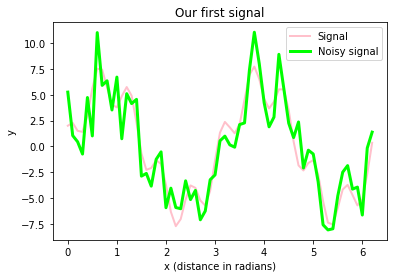

In [5]:
# Your solution 1 here:


<details>
<summary><strong>Toggle solution</strong></summary>

~~~python
# Solution 1:

# Plotting:
fig = plt.figure(1)
fig.clf()

# the main plot commands:
plt.plot(x_values, A_signal,
         label="Signal", lw=2, c="pink") 
plt.plot(x_values, A_signal_noisy, 
         label="Noisy signal", lw=3, c="lime") 

# axis labels and title:
plt.xlabel("x (distance in radians)")
plt.ylabel("y")
plt.title("Our first signal")

# shows a legend:
plt.legend(loc="best")

plt.show()          # finalizes the plot
fig.savefig("my_plot2.pdf", dpi=120)
~~~
    </details>

The figure above includes
- our signal, which is a super-position of actually two prime signals (a sine and a cosine wave with different frequencies and amplitudes)
- our signal with some random ("background") noise.

We will now try to filter our signal in order to
1.  recover the first and the second prime signal, respectively.
2. apply the same filtering operations to the noisy signal.

Let's first create the filter to recover the (lower frequency) sine signal (i.e., low-pass filter):

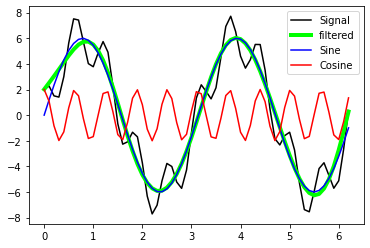

In [6]:
from scipy import signal # put this on top of
                         # your script

fs = x_values.shape[0]  # Sampling frequency
fc = 5  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
filter_order = 10
b, a = signal.butter(filter_order, w, 'low')

# filtering our signal
A_signal_clean = signal.filtfilt(b, a, A_signal)

plt.plot(x_values, A_signal, label='Signal', c="k")
plt.plot(x_values, A_signal_clean, label='filtered',
         c = "lime", lw=4)
plt.plot(x_values, A_sin, label='Sine', c="blue")
plt.plot(x_values, A_cos, label='Cosine', c="red")
plt.legend(loc="best")

With the filter settings provided we are able to recover the sine-signal from `A_signal`. 


In order to create a corresponding high-pass filter to also recover the high-frequency cosine signal, we would have to repeat all filter relevant commands from above. That's actually not the way how we should do. Instead, it would be convenient if we would have our own filter-function, so that we don't have to repeat all these complex steps.

## Exercise 2
1. Recap the _Function definition_ chapter from our _Python Basics_ course. 
2. Write a function that performs the low-pass filtering from above. Define the function in this way that the following arguments must be passed as input parameters: 
    - `sampling_freq` for the sampling frequency,
    - `cutoff_freq` for the cut-off frequency of the filter,
    - `filter_order` for the filter order, and
    - `input_signal` for the input signal, that has to be processed
    - `kind` for the type of the filter to be applied (either `low` or `high`)
3. Apply your newly created function to `A_signal`, once for low-pass filtering the signal, and once for high-pass filtering it, and add corresponding plotting commands to plot
    - the unimpaired signal `A_signal`,
    - the high-pass filtered signal (e.g., `A_clean1`),
    - the low-pass filtered signal (e.g., `A_clean2`), and
    - a cosine and a sine wave for comparison.
4. Apply your filter to the noisy signal `A_signal_noisy`, again both for low- and high-pass filtering the signal. In a new plot window, plot, 
    - the noisy signal `A_signal_noisy`,
    - the high-pass filtered signal (e.g., `A_clean1_noisy`),
    - the low-pass filtered signal (e.g., `A_clean2_noisy`), and
    - a cosine and a sine wave for comparison.
    What do you notice?

In [7]:
# Your solution 2.2 here:


<details>
<summary><strong>Toggle solution</strong></summary>

~~~python
# Solution 2.2:
def my_filter(sampling_freq, cutoff_freq,
              filter_order, input_signal, kind):
    """ Function for optionally high- or low-pass
        filter a given input signal
        
        sampling_freq: Sampling frequency
        cutoff_freq:   Cut-off frequency of the filter
        filter_order:  Order of the filter
        input_signal:  Signal to filter
        kind:          "high" or "low"
    """
    fc = cutoff_freq
    fs = sampling_freq
    
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(filter_order, w, kind)
    
    # filtering the signal
    filtered = signal.filtfilt(b, a, input_signal)
    
    return filtered
~~~
</details>

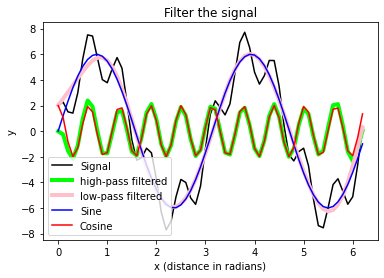

In [8]:
# Your solution 2.3 here:


<details>
<summary><strong>Toggle solution</strong></summary>

~~~python
# Solution 2.3:
# Apply the filter function:
A_clean1=my_filter(sampling_freq = x_values.shape[0], 
               cutoff_freq = 5, filter_order = 10,
               input_signal = A_signal, kind = "high")

A_clean2=my_filter(sampling_freq = x_values.shape[0], 
               cutoff_freq = 5, filter_order = 10,
               input_signal = A_signal, kind = "low")
    
# Plotting:
fig = plt.figure(1)
fig.clf()

# the main plot commands:
plt.plot(x_values, A_signal, label='Signal', c="k")
plt.plot(x_values, A_clean1, label='high-pass filtered',
         c = "lime", lw=4)
plt.plot(x_values, A_clean2, label='low-pass filtered',
         c = "pink", lw=4)
plt.plot(x_values, A_sin, label='Sine', c="blue")
plt.plot(x_values, A_cos, label='Cosine', c="red")
plt.legend(loc="best")

# axis labels and title:
plt.xlabel("x (distance in radians)")
plt.ylabel("y")
plt.title("Filter the signal")

# shows a legend:
plt.legend(loc="best")

plt.show()          # finalizes the plot
fig.savefig("my_plot3.pdf", dpi=120)
~~~
</details>

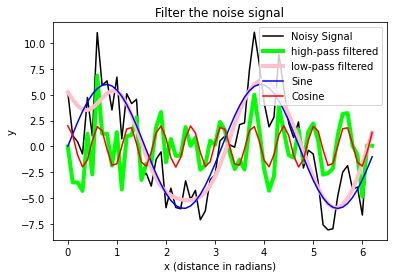

In [9]:
# Your solution 2.4 here:


<details>
<summary><strong>Toggle solution</strong></summary>

~~~python
# Solution 2.4:
A_clean1_noisy=my_filter(sampling_freq = x_values.shape[0], 
               cutoff_freq = 5, filter_order = 10,
               input_signal = A_signal_noisy, 
               kind = "high")

A_clean2_noisy=my_filter(sampling_freq = x_values.shape[0], 
               cutoff_freq = 5, filter_order = 10,
               input_signal = A_signal_noisy, 
               kind = "low")

# Plotting:
fig = plt.figure(1)
fig.clf()

# the main plot commands:
plt.plot(x_values, A_signal_noisy, 
         label='Noisy Signal', c="k")
plt.plot(x_values, A_clean1_noisy, label='high-pass filtered',
         c = "lime", lw=4)
plt.plot(x_values, A_clean2_noisy, label='low-pass filtered',
         c = "pink", lw=4)
plt.plot(x_values, A_sin, label='Sine', c="blue")
plt.plot(x_values, A_cos, label='Cosine', c="red")
plt.legend(loc="best")

# axis labels and title:
plt.xlabel("x (distance in radians)")
plt.ylabel("y")
plt.title("Filter the noise signal")

# shows a legend:
plt.legend(loc="best")

plt.show()          # finalizes the plot
fig.savefig("my_plot4.pdf", dpi=120)
~~~
<details>

<div class="alert alert-block alert-info">
<b>Advice:</b> Matplotlib commands can grow big very quickly. It's therefore often usefull to plug these commands into a function definition in order to keep your script readable and especially when you need to repeat your plot command(s) several times within your script.
</div>

## Exercise 3
1. Please download the data in the Nextcloud folder "Data/Pandas_3/".
2. Write a script, the reads the file "mouse_1_odorA_3_results.xlsx" into a Pandas DataFrame. 
3. Iterate over the keys of the DataFrame (here called `df`) via
   ```python 
        for key in df.keys():
           plt.plot(time, df[key])
    ```
    and plot each column of the read Excel file data into one figure. Set an appropriate titel and x- and y-labels.
    Use the sample frequency `sampling_rate = 30.1` (unit: [1/s]) to construct the corresponding `time` array:
    ```python 
        time = np.arange(df.shape[0]) / sampling_rate
    ```
4. Visit the documentation website https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.medfilt.html and read how to apply a 1D median filter to a given data array. Apply this filter to each column of the data and plot the filtered results into a new figure.
5. Apply the `my_filter` function, that we have written above, to the data and plot, again, the results into a new figure.
6. Save each of your three figures into a separate PDF file.

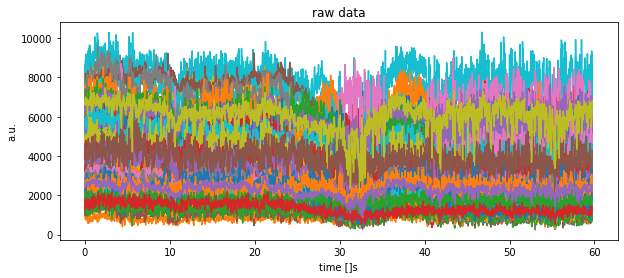

<Figure size 432x288 with 0 Axes>

In [10]:
# Solution 2.2-2.3:
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# %% DEFINE PATHS
"""Define file paths:"""
file_path = "Data/Pandas_3/"
file_name = "mouse_1_odorA_3_results.xlsx"   
file_1 = os.path.join(file_path, file_name)

# %% DATA READING
""" Read the Excel files with Pandas into a Pandas Dataframe:"""
df = pd.read_excel(file_1, engine='openpyxl')
sampling_rate = 30.1
time = np.arange(df.shape[0])/sampling_rate

# %% SOME PLOTS
fig=plt.figure(1,figsize=(10,4))
plt.clf()
for key in df.keys():
    plt.plot(time, df[key])
plt.title("raw data")
plt.xlabel("time []s")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "raw.pdf")

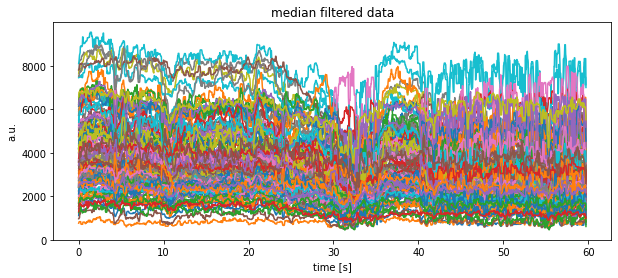

<Figure size 432x288 with 0 Axes>

In [11]:
# Solution 2.4:
fig = plt.figure(2, figsize=(10, 4))
plt.clf()
for key in df.keys():
    plt.plot(time, signal.medfilt(df[key], kernel_size=9))
plt.title("median filtered data")
plt.xlabel("time [s]")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "median filtered.pdf")

In [12]:
df.shape

(1799, 115)

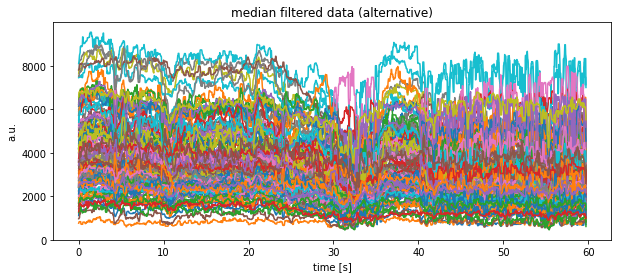

<Figure size 432x288 with 0 Axes>

In [13]:
# Solution 2.4 (Alternative):
# Pre-calculate (and save) median filtered data:

df_medianfiltered = np.zeros(df.shape) #This is not a DataFrame
                                       # any more, but a NUMPY
                                       # arrays

for column, key in enumerate(df.keys()):
    #print(f"column: {column}, key: {key}")
    df_medianfiltered[:, column] = \
           signal.medfilt(df[key], kernel_size=9)

fig = plt.figure(2, figsize=(10, 4))
plt.clf()
for column, key in enumerate(df.keys()):
    #df_medianfiltered[:, column] = \
    #       signal.medfilt(df[key], kernel_size=9)
    plt.plot(time, df_medianfiltered[:, column])
plt.title("median filtered data (alternative)")
plt.xlabel("time [s]")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "median filtered (alt).pdf")

In [14]:
# Example of exporting our processed data into a new Excel file:
df_medianfiltered_out_df = pd.DataFrame(data=df_medianfiltered)
df_medianfiltered_out_df.to_excel("data_medianfiltered.xlsx")
"""Note, for initial call of '.to_excel' you need to install
   the package/module 'xlwt' """
df_medianfiltered_out_df

,0,1,2,3,4,5,6,7,8,9,...,105,106,107,108,109,110,111,112,113,114
0,1110.152,762.414,1903.114,2631.209,1708.880,966.000,2482.405,2381.113,1976.626,2100.812,...,3571.198,2519.204,2708.501,6584.719,2276.359,2110.584,2429.743,1564.950,1290.950,2476.175
1,1270.931,801.291,1903.114,2832.755,1770.490,993.152,2505.907,2543.663,2012.407,2139.024,...,3571.198,2776.846,2749.847,6784.371,2383.808,2313.866,2574.694,1697.931,1429.757,2511.010
2,1270.931,830.725,1903.114,3120.209,1787.659,993.152,2505.907,2543.663,2117.111,2169.277,...,3626.781,2853.312,2808.032,6784.371,2402.242,2445.819,2654.558,1697.931,1650.405,2552.793
3,1343.828,830.725,1903.114,3312.882,1787.659,1016.917,2505.907,2580.418,2117.111,2169.277,...,3685.615,2952.099,2836.334,6784.371,2402.242,2445.819,2654.558,1750.366,1666.834,2552.793
4,1343.828,830.725,1903.114,3312.882,1935.615,1199.434,2545.651,2692.889,2117.111,2169.277,...,4044.885,2970.452,2839.309,6818.234,2402.242,2445.819,2654.558,1903.947,1666.834,2554.529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1794,825.336,953.043,1844.968,1405.873,1888.199,915.748,1884.153,1681.839,1091.154,1754.409,...,3382.917,2520.372,2519.276,6114.663,1779.719,2101.879,2507.723,1691.011,1188.669,2330.131
1795,825.336,953.043,1844.968,1405.873,1829.788,915.748,1884.153,1671.597,1054.562,1738.361,...,3382.917,2520.372,2474.510,6114.663,1772.447,2101.879,2507.723,1691.011,1188.669,2330.131
1796,825.336,953.043,1844.968,1405.873,1802.767,915.748,1884.153,1665.579,1041.919,1738.361,...,2857.292,2520.372,2472.325,5955.802,1672.093,2101.879,2352.427,1684.099,1116.524,2330.131
1797,825.336,953.043,1844.968,1257.936,1795.806,915.748,1884.153,1665.205,1015.191,1730.892,...,2839.021,2520.372,2442.051,5845.568,1544.823,2018.691,2312.262,1667.653,997.586,2327.285


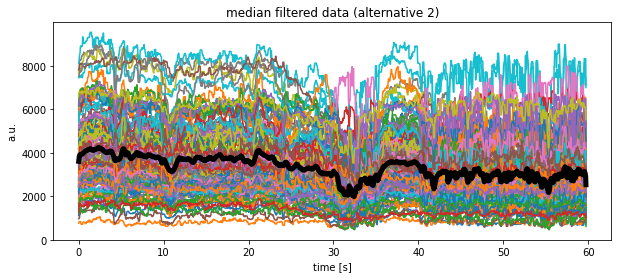

<Figure size 432x288 with 0 Axes>

In [15]:
# for the sake of curiosity, let's plot the Grand Average:
fig = plt.figure(2, figsize=(10, 4))
plt.clf()
for column, key in enumerate(df.keys()):
    plt.plot(time, df_medianfiltered[:, column])
plt.plot(time, df_medianfiltered.mean(axis=1), 'k', lw=5)
plt.title("median filtered data (alternative 2)")
plt.xlabel("time [s]")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "median filtered (alt 2).pdf")

**WRONG!!!!** ⟶ A note: Pandas has also its own Median-command. If you are interested, take a look at:
https://pandas.pydata.org/pandas-docs/version/0.17.0/generated/pandas.DataFrame.median.html#pandas.DataFrame.median ⟵ **THAT IS WRONG!!!!!** Pandas' median function calculates **THE** median, but does no median filtering! That's a huge difference compared to what I initially thought. Sorry :(((

Another alternative solution would look like as follows, but at the moment I do not understand, why the medians look so different compared to the previous calculations?!

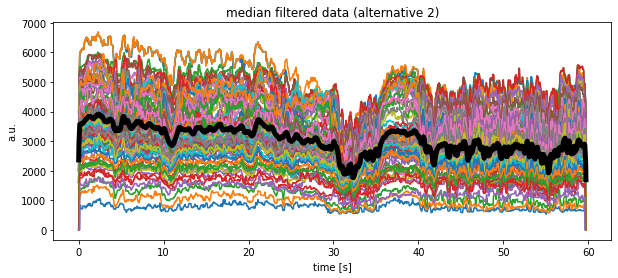

<Figure size 432x288 with 0 Axes>

In [16]:
# Solution 2.4 (Alternative 2):
# Pre-calculate (and save) median filtered data:

df_medianfiltered_3 = signal.medfilt(df, kernel_size=9)
#This is not a DataFrame any more, but a NUMPY array

fig = plt.figure(2, figsize=(10, 4))
plt.clf()
for column in range(df_medianfiltered_3.shape[1]):
    plt.plot(time, df_medianfiltered_3[:, column])
plt.plot(time, df_medianfiltered_3.mean(axis=1), 'k', lw=5)
plt.title("median filtered data (alternative 2)")
plt.xlabel("time [s]")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "median filtered (alt 2).pdf")

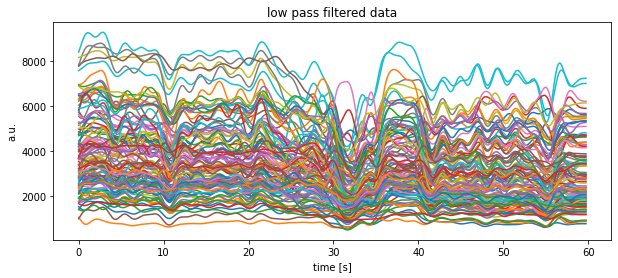

<Figure size 432x288 with 0 Axes>

In [17]:
# Solution 2.5:

# recap our previous designed filter-function:
def my_filter(sampling_freq, cutoff_freq,
              filter_order, input_signal, kind):
    """ Function for optionally high- or low-pass
        filter a given input signal

        sampling_freq: Sampling frequency
        cutoff_freq:   Cut-off frequency of the filter
        filter_order:  Order of the filter
        input_signal:  Signal to filter
        kind:          "high" or "low"
    """
    fc = cutoff_freq
    fs = sampling_freq

    w = fc / (fs / 2)  # Normalize the frequency
    b, a = signal.butter(filter_order, w, kind)

    # filtering the signal
    filtered = signal.filtfilt(b, a, input_signal)

    return filtered

fig = plt.figure(2, figsize=(10, 4))
plt.clf()
for key in df.keys():
    current_signal = my_filter(sampling_freq = sampling_rate, 
                               cutoff_freq = 0.5, 
                               filter_order = 10,
                               input_signal = df[key], 
                               kind = "low")
    plt.plot(time, current_signal)
plt.title("low pass filtered data")
plt.xlabel("time [s]")
plt.ylabel("a.u.")
plt.show()
plt.savefig(file_1 + "low-pass filtered.pdf")

<blockquote>

7. Now, and instead of reading each Excel manually, use the following command to scan for all Excel files in the downloaded folder:
    ```python
    file_name = [f for f in os.listdir(file_path) if f.endswith('.xlsx')]
    ```
    Copy your solutions from above into a new script. Change the new script in that way, that it iterates over all scanned file names in `file_name`, starting from the Pandas reading part. Play a bit around, to see, what is contained in `file_name`. 

    Hint: The automatized reading of the filenames now requires an iteration of your pipeline within a _for_-loop.
</blockquote>

['mouse_1_odorA_1_results.xlsx', 'mouse_1_odorB_1_results.xlsx', 'mouse_1_odorB_3_results.xlsx', 'mouse_1_odorB_4_results.xlsx', 'mouse_1_odorB_5_results.xlsx', 'mouse_1_odorB_2_results.xlsx', 'mouse_1_odorA_3_results.xlsx', 'mouse_1_odorA_4_results.xlsx', 'mouse_1_odorA_5_results.xlsx', 'mouse_1_odorA_2_results.xlsx']


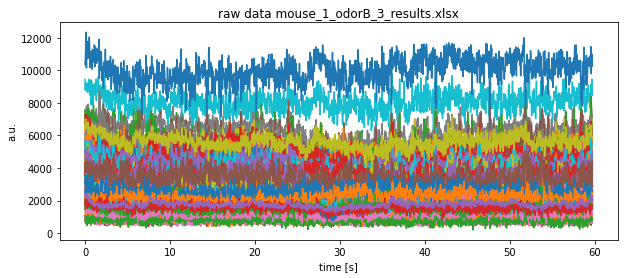

<Figure size 432x288 with 0 Axes>

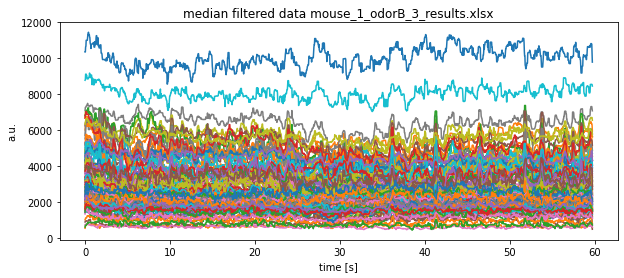

<Figure size 432x288 with 0 Axes>

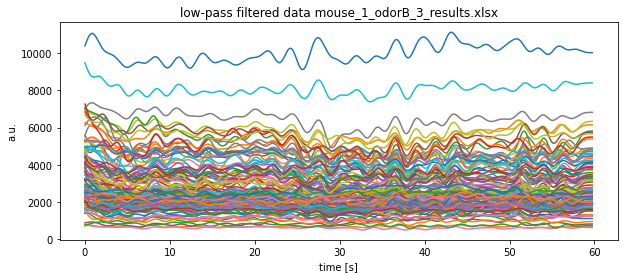

<Figure size 432x288 with 0 Axes>

In [31]:
# Solution 2.8:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


# %% DEFINE PATHS
"""Define file paths:"""
file_path = "Data/Pandas_3/"
file_name = [f for f in os.listdir(file_path) if f.endswith('.xlsx')]

print(file_name)


# %% SOME FUNCTIONS
def my_filter(sampling_freq, cutoff_freq,
              filter_order, input_signal, kind):
    """ Function for optionally high- or low-pass
        filter a given input signal

        sampling_freq: Sampling frequency
        cutoff_freq:   Cut-off frequency of the filter
        filter_order:  Order of the filter
        input_signal:  Signal to filter
        kind:          "high" or "low"
    """
    fc = cutoff_freq
    fs = sampling_freq

    w = fc / (fs / 2)  # Normalize the frequency
    b, a = signal.butter(filter_order, w, kind)

    # filtering the signal
    filtered = signal.filtfilt(b, a, input_signal)

    return filtered

# %% ITERATIVELY DATA READING
""" Read the Excel files with Pandas into a Pandas Dataframe:"""
sampling_rate = 30.1 # in Hertz [1/s]

for file in file_name:
#for file in [file_name[2]]:

    # read the current Excle file:
    current_file = os.path.join(file_path, file)
    df = pd.read_excel(current_file, engine='openpyxl')

    # calculate the current time-array:
    time = np.arange(df.shape[0]) / sampling_rate

    # plots:
    fig = plt.figure(1, figsize=(10, 4))
    plt.clf()
    for key in df.keys():
        plt.plot(time, df[key])
    plt.title(f"raw data {file}")
    plt.xlabel("time [s]")
    plt.ylabel("a.u.")
    plt.show()
    plt.savefig(file_path + file + "raw.pdf")

    fig = plt.figure(2, figsize=(10, 4))
    plt.clf()
    for key in df.keys():
        plt.plot(time, signal.medfilt(df[key], kernel_size=9))
    plt.title(f"median filtered data {file}")
    plt.xlabel("time [s]")
    plt.ylabel("a.u.")
    plt.show()
    plt.savefig(file_path + file + "median filtered.pdf")

    fig = plt.figure(3, figsize=(10, 4))
    plt.clf()
    for key in df.keys():
        current_signal = my_filter(sampling_freq=sampling_rate, 
                                   cutoff_freq=0.5, filter_order=10,
                                   input_signal=df[key], kind="low")
        plt.plot(time, current_signal)
    plt.title(f"low-pass filtered data {file}")
    plt.xlabel("time [s]")
    plt.ylabel("a.u.")
    plt.show()
    plt.savefig(file_path+file+"low pass filtered.pdf")

Here and for the moment, the result of only one Excel file is shown.

## Excursus: Moni's heatmap problem

[Text(0, 0, '0.0'),
 Text(2, 0, '2.0'),
 Text(4, 0, '4.0'),
 Text(6, 0, '6.0'),
 Text(8, 0, '8.0'),
 Text(10, 0, '10.0'),
 Text(12, 0, '12.0'),
 Text(14, 0, '14.0'),
 Text(16, 0, '16.0'),
 Text(18, 0, '18.0')]

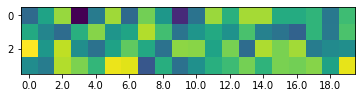

In [1]:
# adapted from https://matplotlib.org/3.1.1/gallery/images_contours_and_fields/image_annotated_heatmap.html
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

data = np.random.randn(4,20)

fig, ax = plt.subplots()
im = ax.imshow(data)

# We want to show all ticks...
sample_rate = 1
xticks = np.arange(0,data.shape[1],2)
xtickslabel = xticks/sample_rate
#xticks = np.arange(0,harvest.shape[0],2)
ax.set_xticks(xticks)

# ... and label them with the respective list entries
ax.set_xticklabels(xtickslabel)